# Convolutional Neural Network - CIFAR-10 Classification

CIFAR-10: 60,000 32x32 colour images in 10 classes
- 50,000 training images | 10,000 test images
- Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

### Importing the libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

In [2]:
tf.__version__

'2.19.0'

In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

## Part 1 - Data Preprocessing

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 26s 0us/step
Training set shape : (50000, 32, 32, 3)  |  Labels: (50000, 1)
Test set shape     : (10000, 32, 32, 3)   |  Labels: (10000, 1)


### Preprocessing the Training set

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

training_set = train_datagen.flow(x_train, y_train, batch_size=64)

### Preprocessing the Test set

In [11]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_set = test_datagen.flow(x_test, y_test, batch_size=64)

## Part 2 - Building the CNN

In [13]:
cnn = models.Sequential()

### Step 1 - First Convolution + Pooling

In [15]:
cnn.add(layers.Input(shape=(32, 32, 3)))
cnn.add(layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
cnn.add(layers.BatchNormalization())
cnn.add(layers.MaxPool2D(pool_size=2, strides=2))

### Step 2 - Second Convolution + Pooling

In [17]:
cnn.add(layers.Conv2D(filters=64, kernel_size=3, activation='relu'))
cnn.add(layers.BatchNormalization())
cnn.add(layers.MaxPool2D(pool_size=2, strides=2))

### Adding a third convolutional layer


In [19]:
cnn.add(layers.Conv2D(filters=128, kernel_size=3, activation='relu'))
cnn.add(layers.BatchNormalization())
cnn.add(layers.MaxPool2D(pool_size=2, strides=2))

### Step 3 - Flattening

In [21]:
cnn.add(layers.Flatten())

### Step 4 - Full Connection

In [23]:
cnn.add(layers.Dense(units=256, activation='relu'))
cnn.add(layers.Dropout(0.5))

cnn.add(layers.Dense(units=128, activation='relu'))
cnn.add(layers.Dropout(0.3))

### Step 5 - Output Layer
10 units with softmax for multi-class classification (instead of 1 unit with sigmoid for binary)

In [25]:
cnn.add(layers.Dense(units=10, activation='softmax'))

In [27]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,658 (1014.29 KB)

 Trainable params: 259,210 (1012.54 KB)

 Non-trainable params: 448 (1.75 KB)

## Part 3 - Training the CNN

### Compiling the CNN
Using `sparse_categorical_crossentropy` for multi-class (instead of `binary_crossentropy`)

In [29]:
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### Training the CNN on the Training set and evaluating it on the Test set

In [31]:
history = cnn.fit(x=training_set, validation_data=test_set, epochs=25)

Epoch 1/25


D:\ANACONDA\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.2953 - loss: 2.0151 - val_accuracy: 0.5124 - val_loss: 1.3735
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.4624 - loss: 1.5041 - val_accuracy: 0.5252 - val_loss: 1.3505
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.5211 - loss: 1.3574 - val_accuracy: 0.6025 - val_loss: 1.1483
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.5602 - loss: 1.2501 - val_accuracy: 0.5426 - val_loss: 1.2983
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.5892 - loss: 1.1817 - val_accuracy: 0.6000 - val_loss: 1.1547
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.6190 - loss: 1.1049 - val_accuracy: 0.6964 - val_loss: 0.8899
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.6336 - loss: 1.0658 - val_accuracy: 0.6618 - val_loss: 0.9389
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.6488 - loss: 1.0320 - val_accurac

## Part 4 - Evaluating the Results

### Plotting Training & Validation Accuracy / Loss

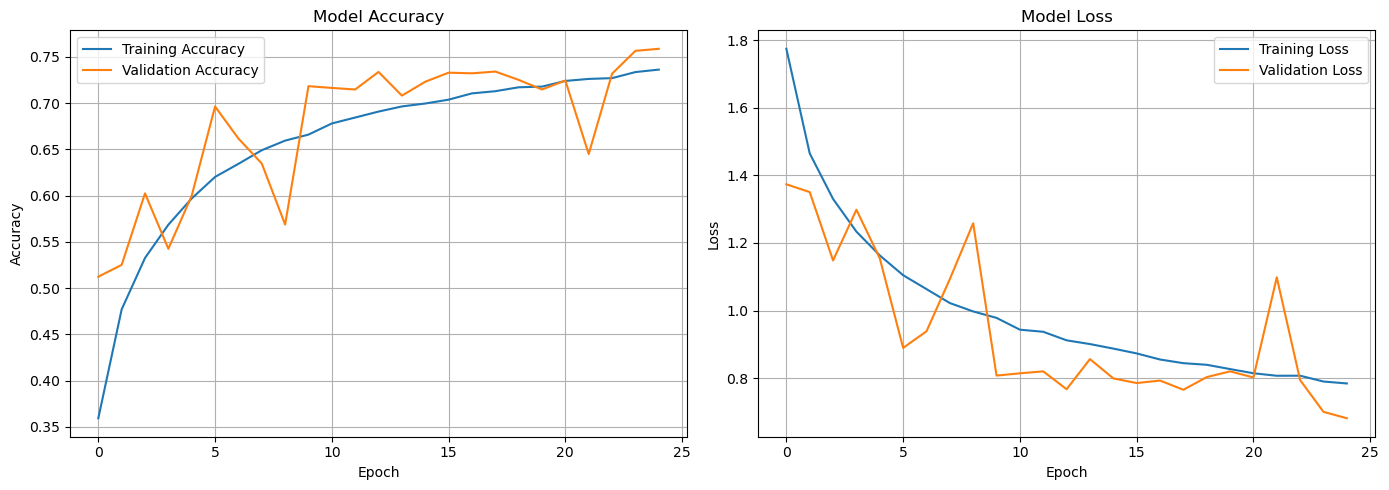

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'],     label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'],     label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Final Test set evaluation

In [35]:
test_loss, test_accuracy = cnn.evaluate(x_test / 255.0, y_test)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7594 - loss: 0.6819

Test Loss     : 0.6819
Test Accuracy : 0.7588


In [37]:
cnn.save('cifar10_cnn_model.keras')

## Part 5 - Making a single prediction

In [39]:
import numpy as np

idx = np.random.randint(0, len(x_test))
test_image = x_test[idx]

# Preprocess: rescale and add batch dimension
test_image_input = test_image.astype('float32') / 255.0
test_image_input = np.expand_dims(test_image_input, axis=0)

# Predict
result = cnn.predict(test_image_input)
predicted_class = np.argmax(result[0])
confidence = result[0][predicted_class] * 100
actual_class = int(y_test[idx][0])

print(f"Predicted class : {class_names[predicted_class]} ({confidence:.1f}% confidence)")
print(f"Actual class    : {class_names[actual_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Predicted class : cat (39.2% confidence)
Actual class    : frog


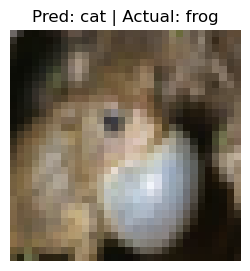

In [41]:
plt.figure(figsize=(3, 3))
plt.imshow(test_image)
plt.title(f"Pred: {class_names[predicted_class]} | Actual: {class_names[actual_class]}")
plt.axis('off')
plt.show()